Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    accuracy_score
)

import cv2
from PIL import Image

os.makedirs("../assets", exist_ok=True)

print("Libraries loaded.")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Libraries loaded.


Load Trained Model

In [2]:
model = tf.keras.models.load_model(
    "../models/best_model.keras"
)

print("Model loaded successfully.")

Model loaded successfully.


Model Summary

In [3]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,339,259 (8.92 MB)

 Trainable params: 662,691 (2.53 MB)

 Non-trainable params: 351,184 (1.34 MB)

 Optimizer params: 1,325,384 (5.06 MB)

Save Model Summary

In [4]:
lines = []

model.summary(
    print_fn=lambda x: lines.append(x)
)

with open("../assets/model_summary.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print("Model summary saved.")

Model summary saved.


Save Model Architecture

In [5]:
tf.keras.utils.plot_model(
    model,
    to_file="../assets/model_architecture.png",
    show_shapes=True,
    show_layer_names=True
)

print("Model architecture saved.")

Model architecture saved.


Load Training Log

In [6]:
df = pd.read_csv("../logs/training_log.csv")

df = df.dropna().reset_index(drop=True)

df.head()

,epoch,accuracy,learning_rate,loss,val_accuracy,val_loss
0,0,0.666833,0.00001,0.826094,0.871167,0.356609
1,1,0.852232,0.00001,0.399892,0.925833,0.213891
2,2,0.892195,0.00001,0.298577,0.947833,0.159949
3,3,0.908947,0.00001,0.255232,0.954833,0.137192
4,4,0.921073,0.00001,0.227466,0.959000,0.121731


Loss Curve

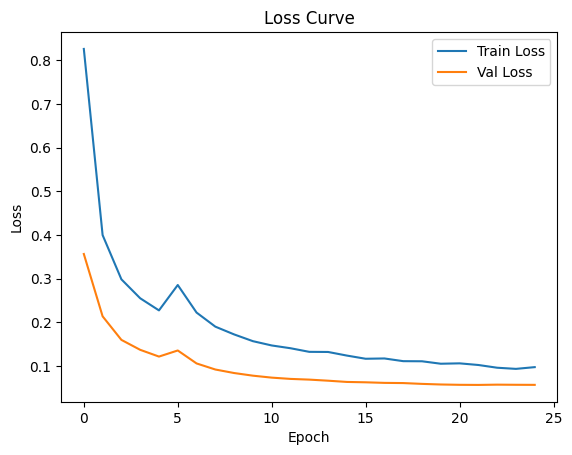

In [7]:
plt.figure()

plt.plot(df["epoch"], df["loss"], label="Train Loss")
plt.plot(df["epoch"], df["val_loss"], label="Val Loss")

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../assets/loss_curve.png")
plt.show()

Accuracy Curve

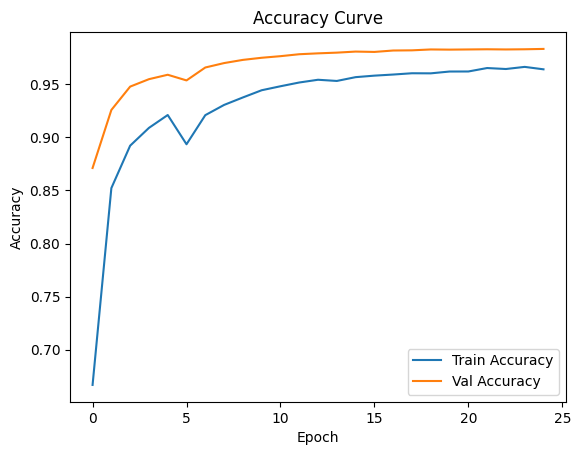

In [8]:
plt.figure()

plt.plot(df["epoch"], df["accuracy"], label="Train Accuracy")
plt.plot(df["epoch"], df["val_accuracy"], label="Val Accuracy")

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("../assets/accuracy_curve.png")
plt.show()

Load Test Dataset

In [9]:
TEST_DIR = "../data/test"

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)


print("Validation dataset loaded.")

Found 3000 files belonging to 3 classes.
Validation dataset loaded.


Predictions

In [10]:
import numpy as np

# CLASS LABELS (MUST MATCH TRAINING ORDER)

CLASS_NAMES = ["cat", "dog", "others"]

# TRUE LABELS

y_true = np.concatenate(
    [y.numpy() for x, y in test_ds],
    axis=0
)

# convert one-hot encoded labels -> class index
if len(y_true.shape) > 1:
    y_true = np.argmax(y_true, axis=1)

# PREDICTIONS

print("Generating predictions...\n")

y_pred_probs = model.predict(test_ds, verbose=1)

# softmax probability -> predicted class index
y_pred = np.argmax(y_pred_probs, axis=1)

# DEBUG INFORMATION

print("\nPredictions generated successfully.")

# Predicted class distribution
print("\nPredicted Class Distribution:")
for idx, count in zip(*np.unique(y_pred, return_counts=True)):
    print(f"{CLASS_NAMES[idx]} ({idx}) : {count}")

# True class distribution
print("\nTrue Class Distribution:")
for idx, count in zip(*np.unique(y_true, return_counts=True)):
    print(f"{CLASS_NAMES[idx]} ({idx}) : {count}")

# Sample predictions
print("\nSample Prediction Probabilities:")
print(y_pred_probs[:10])

# Sample predicted labels
print("\nSample Predicted Classes:")
print([CLASS_NAMES[i] for i in y_pred[:20]])

Generating predictions...

94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step

Predictions generated successfully.

Predicted Class Distribution:
cat (0) : 1001
dog (1) : 1002
others (2) : 997

True Class Distribution:
cat (0) : 1000
dog (1) : 1000
others (2) : 1000

Sample Prediction Probabilities:
[[9.9619448e-01 8.7288943e-05 3.7182330e-03]
 [9.9263895e-01 3.4108525e-03 3.9502978e-03]
 [9.8812044e-01 1.1745259e-02 1.3432527e-04]
 [9.9944812e-01 3.8110436e-04 1.7073585e-04]
 [9.9976867e-01 1.3580509e-04 9.5584815e-05]
 [9.9965703e-01 2.7689113e-05 3.1534012e-04]
 [9.9973553e-01 3.7096565e-06 2.6073301e-04]
 [9.9928111e-01 1.4818443e-06 7.1750797e-04]
 [9.9998629e-01 2.2671010e-08 1.3728577e-05]
 [9.9996352e-01 1.3866027e-05 2.2679978e-05]]

Sample Predicted Classes:
['cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat']


Confusion Matrix

Generating predictions...

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step

Prediction Distribution:
cat (0) : 1001
dog (1) : 1002
others (2) : 997

True Distribution:
cat (0) : 1000
dog (1) : 1000
others (2) : 1000


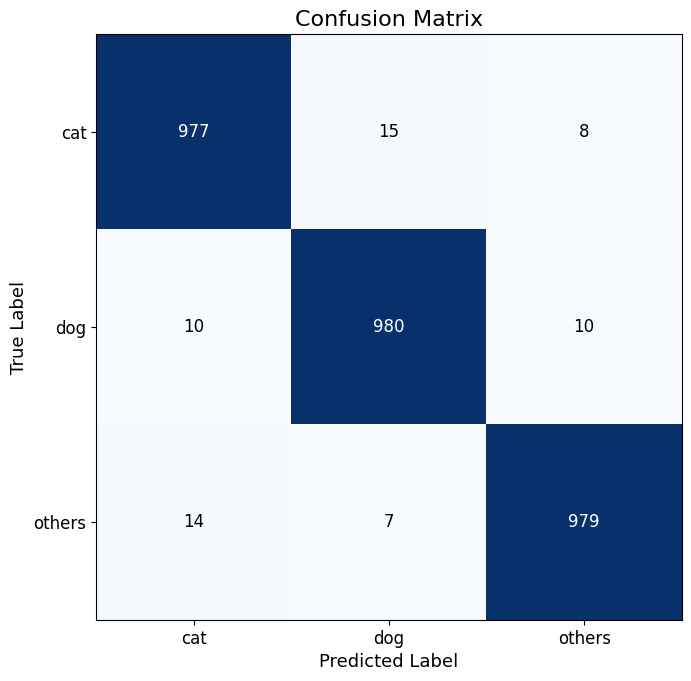

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# CLASS LABELS
CLASS_NAMES = ["cat", "dog", "others"]

# TRUE LABELS

y_true = np.concatenate(
    [y.numpy() for x, y in test_ds],
    axis=0
)

# convert one-hot -> integer labels
if len(y_true.shape) > 1:
    y_true = np.argmax(y_true, axis=1)

# PREDICTIONS

print("Generating predictions...\n")

y_pred_probs = model.predict(test_ds, verbose=1)

# probability -> class index
y_pred = np.argmax(y_pred_probs, axis=1)

# DEBUG CHECK

print("\nPrediction Distribution:")
for idx, count in zip(*np.unique(y_pred, return_counts=True)):
    print(f"{CLASS_NAMES[idx]} ({idx}) : {count}")

print("\nTrue Distribution:")
for idx, count in zip(*np.unique(y_true, return_counts=True)):
    print(f"{CLASS_NAMES[idx]} ({idx}) : {count}")

# CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

# PLOT

plt.figure(figsize=(7, 7))

plt.imshow(cm, cmap="Blues")

# axis labels
plt.xticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=CLASS_NAMES,
    fontsize=12
)

plt.yticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=CLASS_NAMES,
    fontsize=12
)

# numbers inside cells
threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=12
        )

plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)

plt.tight_layout()

# save image
plt.savefig("../assets/confusion_matrix.png", dpi=300)

plt.show()

Classification Report

In [12]:
report = classification_report(
    y_true,
    y_pred,
    target_names=["cat", "dog", "others"]
)

print(report)

with open("../assets/classification_report.txt", "w") as f:
    f.write(report)

              precision    recall  f1-score   support

         cat       0.98      0.98      0.98      1000
         dog       0.98      0.98      0.98      1000
      others       0.98      0.98      0.98      1000

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



ROC Curve

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step


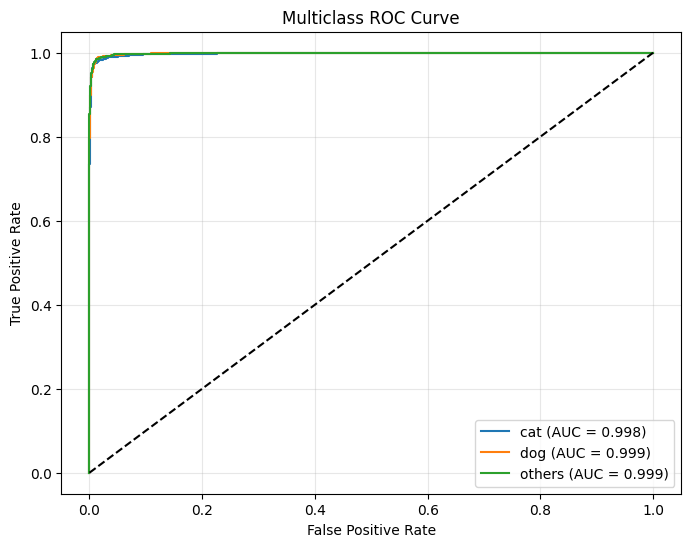

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import numpy as np

# CLASS NAMES

CLASS_NAMES = ["cat", "dog", "others"]

# TRUE LABELS

y_true = np.concatenate(
    [y.numpy() for x, y in test_ds],
    axis=0
)

# convert one-hot -> class index
if len(y_true.shape) > 1:
    y_true = np.argmax(y_true, axis=1)

# PREDICTIONS

y_pred_probs = model.predict(test_ds)

# BINARIZE LABELS

y_true_bin = label_binarize(
    y_true,
    classes=[0, 1, 2]
)

# PLOT ROC CURVE

plt.figure(figsize=(8, 6))

for i in range(len(CLASS_NAMES)):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_pred_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{CLASS_NAMES[i]} (AUC = {roc_auc:.3f})"
    )

# random baseline
plt.plot([0, 1], [0, 1], "k--")

# STYLING

plt.title("Multiclass ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

# save
plt.savefig("../assets/roc_curve.png", dpi=300)

plt.show()

Final Accuracy

In [14]:
acc = accuracy_score(y_true, y_pred)

print(f"Final Accuracy: {acc:.4f}")

Final Accuracy: 0.9787
